In [ ]:
import pandas as pd # for data handaling
import numpy as np # for numaric operation
# And both matplotlib and seaborn for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Here i used pandas and numpy for data preprocessing and seaborn/matplotlib for data visualization

In [ ]:
# Here we Removes warnings and improves plot appearance.
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


In [ ]:
# Here we lode the csv file which contains our data
df=pd.read_csv("AIML Dataset.csv")

In [4]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# Now we checked the  data types and ensured no incorrect formats before preprocessing.”
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
# Here are we checking is there any missing values in our data
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.shape[0]

6362620

In [10]:
# now just quickly check the persentage of the data which is Fraud in our dataframe
round((df['isFraud'].value_counts()[1]/df.shape[0])*100,2)

np.float64(0.13)

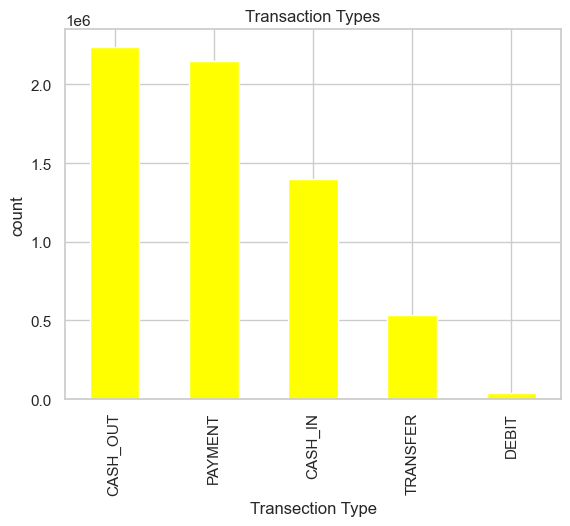

In [11]:
df['type'].value_counts().plot(kind="bar",title="Transaction Types",color='yellow')
plt.xlabel('Transection Type')
plt.ylabel('count')
plt.show()

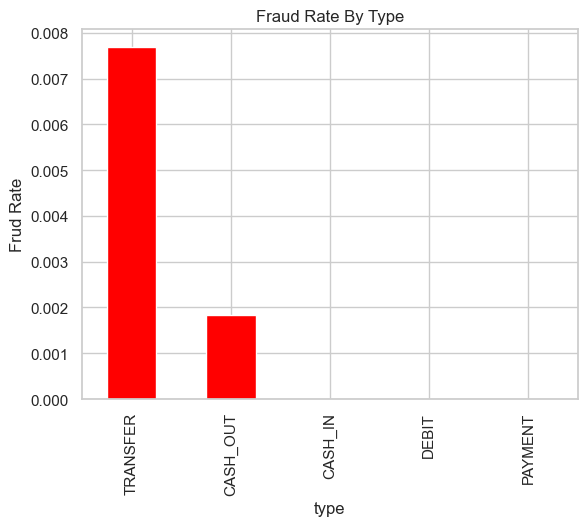

In [12]:
# we will check which type of fraud is happans the most 
fraud_by_typ=df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_typ.plot(kind='bar',title="Fraud Rate By Type",color="red")
plt.ylabel("Frud Rate")
plt.show()

In [13]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

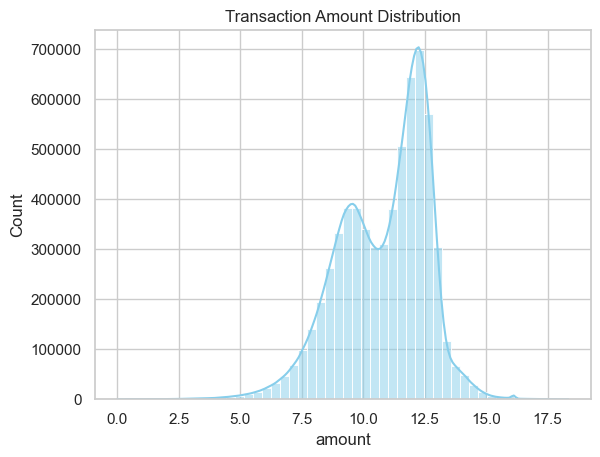

In [14]:
sns.histplot(np.log1p(df['amount']),bins=50,kde=True,color='skyblue')
plt.title("Transaction Amount Distribution")
plt.show()

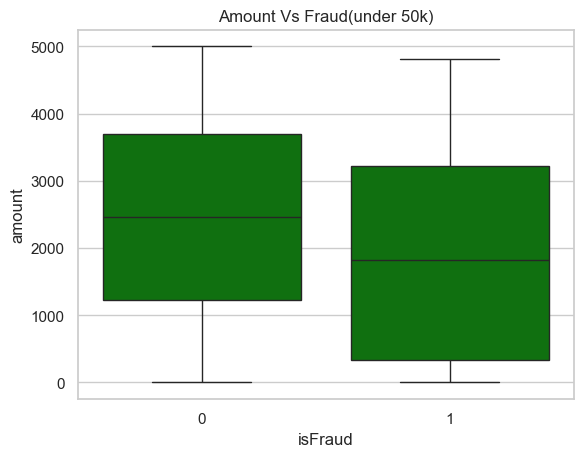

In [15]:
sns.boxplot(data=df[df['amount']<5000],x="isFraud",y="amount",color='green')
plt.title('Amount Vs Fraud(under 50k)')
plt .show()

In [16]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [17]:
df["Balance-Dif-Org"]=df["oldbalanceOrg"]-df["newbalanceOrig"]
df["Balance-Dif-Dest"]=df["newbalanceDest"]-df["oldbalanceDest"]

In [18]:
(df["Balance-Dif-Org"]<0).sum()

np.int64(1399253)

In [19]:
(df["Balance-Dif-Dest"]<0).sum()

np.int64(1238864)

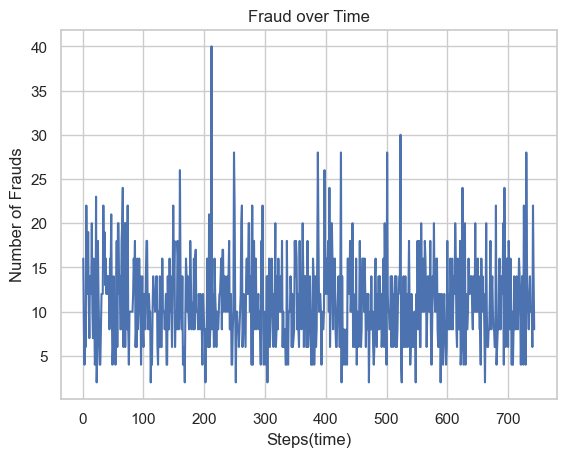

In [20]:
# now we will check if our Frauds are time dependent
Frauds_Acco_step = df[df['isFraud']==1]["step"].value_counts().sort_index()
plt.plot(Frauds_Acco_step.index,Frauds_Acco_step,label='Frauds according to the steps')
plt.xlabel("Steps(time)")
plt.ylabel("Number of Frauds")
plt.title("Fraud over Time")
plt.grid(True)
plt.show()


In [21]:
# scince the Frauds are not time dependent we will remove the step column scince its no use 
df.drop(columns="step",inplace=True)

In [22]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Balance-Dif-Org,Balance-Dif-Dest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [23]:
# now we will try to find the customer who made most the transaction (like top senders and top recivers)
# first top sendrs
top_senders=df['nameOrig'].value_counts().head()

In [24]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
Name: count, dtype: int64

In [25]:
top_recivers=df['nameDest'].value_counts().head()

In [26]:
top_recivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
Name: count, dtype: int64

In [27]:
# Now lets check fraud made to the customer
Frauds_users=df[df['isFraud']==1]['nameOrig'].value_counts().head(10)

In [28]:
Frauds_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [29]:
# Now lets see the the transfer and cash-out 
#  Beacuse Most frauds in our data  occurs at the point of transfer and cash-out. 
fraud_typs=df[df['type'].isin(['TRANSFER','CASH_OUT'])]

In [30]:
fraud_typs['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

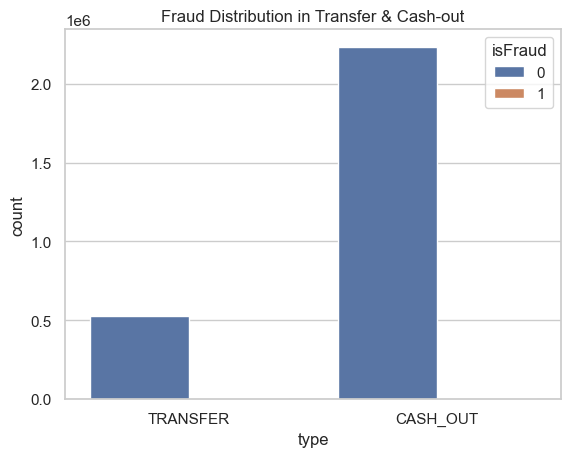

In [31]:

sns.countplot(data=fraud_typs,x="type",hue="isFraud")
plt.title('Fraud Distribution in Transfer & Cash-out')
plt.show()

In [32]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'Balance-Dif-Org', 'Balance-Dif-Dest'],
      dtype='object')

In [33]:
#now we are filtr numaric column so that we can find the relation yes

corr = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()


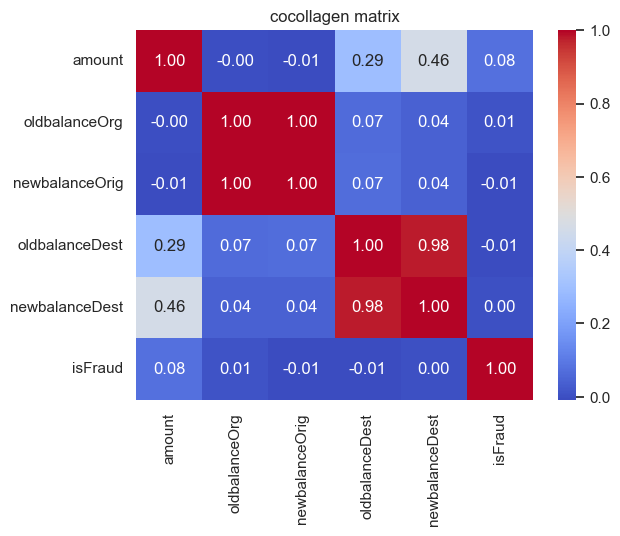

In [34]:
# Now we can view the cocollagen matrix using a hitmap
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("cocollagen matrix")
plt.show()

In [35]:
zero_after_transfar=df[
    (df['oldbalanceOrg']>0)&
    (df['newbalanceOrig']==0)&
    (df['type'].isin(['TRANSFER','CASH_OUT']))
]

In [36]:
len(zero_after_transfar)

1188074

In [37]:
zero_after_transfar.head(5)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Balance-Dif-Org,Balance-Dif-Dest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


### Now we will strat the feature enginerring part

In [38]:
# moduls we need for feature enginerring
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [39]:
df.head(5)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Balance-Dif-Org,Balance-Dif-Dest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [40]:
# first we will drope some of the unwanted columns which we not going to use during model tranning
df_model= df.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1)

In [41]:
df_model.head(5)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,Balance-Dif-Org,Balance-Dif-Dest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [42]:
# Now we will set the catagorical and numarical columns and split them which will be our feature
catgorical=['type']
numarical=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [43]:
y=df_model['isFraud']
x=df_model.drop('isFraud',axis=1)

In [44]:
# Here we will do the train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,stratify=y)

In [45]:
preprocesser=ColumnTransformer(
    transformers =[
    ('num',StandardScaler(),numarical),
    ('cata',OneHotEncoder(drop='first'),catgorical)
    ],
    remainder='drop'

)

In [46]:
# importing our model
from sklearn.linear_model import LogisticRegression

In [47]:
# now we will make the model pipeline
Pipeline= Pipeline([
    ('prep',preprocesser),
    ('clf',LogisticRegression(class_weight='balanced',max_iter=1000))
])

In [48]:
# here we will train our model with preprocessing
Pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cata', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [49]:
# now we can predict using our model
y_pred=Pipeline.predict(x_test)

In [50]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [51]:
confusion_matrix(y_test,y_pred)

array([[1804067,  102255],
       [    152,    2312]])

In [52]:
Pipeline.score(x_test,y_test)

0.9463496693710034

In [53]:
# now we export our pipeline
import joblib

joblib.dump(Pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']